In [3]:
# Step 1: Environment setup
# Google Drive is mounted so that the dataset and all derived outputs
# are stored persistently and survive Colab session resets. The
# huggingface_hub library is installed to provide access to the
# McAuley Amazon Reviews 2023 dataset.

from google.colab import drive

# Google Drive is mounted to the Colab session
drive.mount('/content/drive')

# The HuggingFace Hub client is installed for dataset retrieval
!pip install huggingface_hub -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Step 2: Dataset retrieval
# The Home & Kitchen reviews file is downloaded from the HuggingFace
# repository hosting the McAuley Amazon Reviews 2023 dataset. The
# project directory structure is created in Google Drive so that all
# data and outputs are stored persistently.

import os
from huggingface_hub import hf_hub_download

# The project data and outputs directories are created if not present
data_dir = "/content/drive/MyDrive/MSc-Project/data"
outputs_dir = "/content/drive/MyDrive/MSc-Project/outputs"
os.makedirs(data_dir, exist_ok=True)
os.makedirs(outputs_dir, exist_ok=True)

# The Home & Kitchen review file is retrieved from the HuggingFace Hub
file_path = hf_hub_download(
    repo_id="McAuley-Lab/Amazon-Reviews-2023",
    filename="raw/review_categories/Home_and_Kitchen.jsonl",
    repo_type="dataset"
)

print("Source file downloaded to:", file_path)
print("File size (GB):", round(os.path.getsize(file_path) / (1024**3), 2))

raw/review_categories/Home_and_Kitchen.j(…): reconstructing file:   0%|          |  0.00B / 31.4GB            

raw/review_categories/Home_and_Kitchen.j(…): downloading bytes:           |  0.00B            

Source file downloaded to: /root/.cache/huggingface/hub/datasets--McAuley-Lab--Amazon-Reviews-2023/snapshots/2b6d039ed471f2ba5fd2acb718bf33b0a7e5598e/raw/review_categories/Home_and_Kitchen.jsonl
File size (GB): 29.25


In [5]:
# Step 3: Random sample extraction using reservoir sampling
# The source file is approximately 31.4 GB and cannot be loaded into
# memory in full. Reservoir sampling is applied, which produces a
# uniform random sample of fixed size from a data stream of unknown
# length in a single pass and in constant memory. Every review in the
# file therefore has an equal probability of selection, which
# eliminates the ordering bias associated with sequential extraction.

import pandas as pd
import json
import random

sample_size = 100000

# A fixed random seed is set so that the sample is fully reproducible
random.seed(42)

reservoir = []

# The file is streamed line by line. Raw lines are retained rather than
# parsed at this stage, as parsing every record would be computationally
# prohibitive; only the selected sample is parsed afterwards.
with open(file_path, "r") as f:
    for i, line in enumerate(f):
        if i < sample_size:
            # The reservoir is filled with the first n records
            reservoir.append(line)
        else:
            # Each subsequent record replaces a randomly chosen reservoir
            # element with probability n/i, preserving uniform selection
            j = random.randint(0, i)
            if j < sample_size:
                reservoir[j] = line

        # Progress is reported periodically to monitor the stream
        if (i + 1) % 5000000 == 0:
            print(f"Records streamed: {i + 1:,}")

total_records = i + 1
print(f"\nTotal records in source file: {total_records:,}")
print(f"Records selected for sample:  {len(reservoir):,}")
print(f"Sampling fraction:            {len(reservoir) / total_records:.4%}")

# The selected records are parsed into a DataFrame
reviews_df = pd.DataFrame([json.loads(line) for line in reservoir])

# The random sample is saved to Google Drive
sample_path = "/content/drive/MyDrive/MSc-Project/data/home_kitchen_sample_100k.csv"
reviews_df.to_csv(sample_path, index=False)

print("\nSample shape:", reviews_df.shape)
print("Saved to:", sample_path)
reviews_df.head()

Records streamed: 5,000,000
Records streamed: 10,000,000
Records streamed: 15,000,000
Records streamed: 20,000,000
Records streamed: 25,000,000
Records streamed: 30,000,000
Records streamed: 35,000,000
Records streamed: 40,000,000
Records streamed: 45,000,000
Records streamed: 50,000,000
Records streamed: 55,000,000
Records streamed: 60,000,000
Records streamed: 65,000,000

Total records in source file: 67,409,944
Records selected for sample:  100,000
Sampling fraction:            0.1483%

Sample shape: (100000, 10)
Saved to: /content/drive/MyDrive/MSc-Project/data/home_kitchen_sample_100k.csv


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,looks good,easy to see and people comment on the style,[],B00QGP1G4C,B00QGP1G4C,AFSCIIUVQYVEVKSUYGVEC7G2QS4A,1433791491000,0,True
1,5.0,If you can't get the part you need then it may...,I used the bowl on the old carb because the bo...,[],B0184E3FT6,B0184E3FT6,AGJFAZIZMXOLMBMKIH2HTYJYDXWQ,1538045567884,0,True
2,1.0,Do not buy,The colors are washed out and mire brown than ...,[],B096VLVJLK,B096VLVJLK,AEPIS7WVX32OKME3SZRLLSFL6HJQ,1636221610720,0,True
3,5.0,Worth while..,A real pain to put together but well worth it....,[],B017SHFIVS,B017SHFIVS,AHZ7342IUEEQ3QZLKZEA6NRN67ZA,1471563412000,0,True
4,5.0,Five Stars,My daughter loves them.,[],B000NPO39Q,B000NPO39Q,AFJ3MZ3CUNV2NNNZBUT3IRHH4NVQ,1421264520000,0,True


In [6]:
# Step 4: Verification of the saved sample
# The saved sample is reloaded from Google Drive to confirm that it has
# been written correctly and can be restored in future sessions without
# re-streaming the source file. The path used here matches the save
# location in the preceding step exactly, ensuring that all subsequent
# analysis operates on the intended sample.

import pandas as pd

# The sample is reloaded from the project data directory
sample_path = "/content/drive/MyDrive/MSc-Project/data/home_kitchen_sample_100k.csv"
reviews_df = pd.read_csv(sample_path)

print("Sample reloaded from Drive:", reviews_df.shape)

# The temporal coverage of the sample is reported as evidence that the
# random draw spans the full history of the source file
reviews_df["review_date"] = pd.to_datetime(reviews_df["timestamp"], unit="ms")
print("Earliest review:", reviews_df["review_date"].min().date())
print("Latest review:  ", reviews_df["review_date"].max().date())

reviews_df.head()

Sample reloaded from Drive: (100000, 10)
Earliest review: 2001-04-11
Latest review:   2023-09-05


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,review_date
0,5.0,looks good,easy to see and people comment on the style,[],B00QGP1G4C,B00QGP1G4C,AFSCIIUVQYVEVKSUYGVEC7G2QS4A,1433791491000,0,True,2015-06-08 19:24:51.000
1,5.0,If you can't get the part you need then it may...,I used the bowl on the old carb because the bo...,[],B0184E3FT6,B0184E3FT6,AGJFAZIZMXOLMBMKIH2HTYJYDXWQ,1538045567884,0,True,2018-09-27 10:52:47.884
2,1.0,Do not buy,The colors are washed out and mire brown than ...,[],B096VLVJLK,B096VLVJLK,AEPIS7WVX32OKME3SZRLLSFL6HJQ,1636221610720,0,True,2021-11-06 18:00:10.720
3,5.0,Worth while..,A real pain to put together but well worth it....,[],B017SHFIVS,B017SHFIVS,AHZ7342IUEEQ3QZLKZEA6NRN67ZA,1471563412000,0,True,2016-08-18 23:36:52.000
4,5.0,Five Stars,My daughter loves them.,[],B000NPO39Q,B000NPO39Q,AFJ3MZ3CUNV2NNNZBUT3IRHH4NVQ,1421264520000,0,True,2015-01-14 19:42:00.000


# **EDA - Verified Vs Unverified**

In [9]:
# Step 5: Distribution of verified and unverified reviews
# Following supervisor guidance, the verified_purchase field is examined
# to establish the balance between verified and unverified reviews in
# the sample. Establishing this split is a necessary first step before
# assessing whether unverified reviews introduce bias into the
# subsequent text analysis.

# The distribution of verified and unverified reviews is counted
verified_counts = reviews_df["verified_purchase"].value_counts()
verified_pct = reviews_df["verified_purchase"].value_counts(normalize=True) * 100

print("Review counts by verification status:")
print(verified_counts)
print("\nPercentage split:")
print(verified_pct.round(2))

Review counts by verification status:
verified_purchase
True     93331
False     6669
Name: count, dtype: int64

Percentage split:
verified_purchase
True     93.33
False     6.67
Name: proportion, dtype: float64


In [10]:
# Step 6: Comparison of key characteristics between groups
# Verified and unverified reviews are compared across rating, review
# length, and helpful votes to determine whether the two groups differ
# systematically. Review length and word count are derived from the
# review text as proxies for the depth of feedback, which is relevant
# to the subsequent natural language processing analysis.

# Review length is derived as the character count of the review text
reviews_df["review_length"] = reviews_df["text"].astype(str).str.len()

# Word count is derived as a secondary measure of review depth
reviews_df["word_count"] = reviews_df["text"].astype(str).str.split().str.len()

# The two groups are compared across the selected characteristics
comparison = reviews_df.groupby("verified_purchase").agg(
    review_count=("rating", "size"),
    mean_rating=("rating", "mean"),
    median_rating=("rating", "median"),
    mean_length=("review_length", "mean"),
    mean_words=("word_count", "mean"),
    mean_helpful_votes=("helpful_vote", "mean")
).round(2)

print("Comparison of verified and unverified reviews:")
comparison

Comparison of verified and unverified reviews:


,review_count,mean_rating,median_rating,mean_length,mean_words,mean_helpful_votes
verified_purchase,,,,,,
False,6669,4.06,5.0,375.59,69.96,2.08
True,93331,4.18,5.0,164.76,30.96,1.01


In [11]:
# Step 7: Statistical significance testing
# Independent t-tests and Mann-Whitney U tests are applied to determine
# whether the observed differences between verified and unverified
# reviews are statistically significant. The Mann-Whitney U test is
# included as a non-parametric alternative, since review length is
# unlikely to follow a normal distribution.

from scipy import stats

verified = reviews_df[reviews_df["verified_purchase"] == True]
unverified = reviews_df[reviews_df["verified_purchase"] == False]

# Each characteristic is tested for a significant difference between groups
for col in ["rating", "review_length", "word_count", "helpful_vote"]:
    t_stat, t_p = stats.ttest_ind(verified[col], unverified[col], equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(verified[col], unverified[col], alternative="two-sided")
    print(f"{col}:")
    print(f"   t-test p-value        = {t_p:.2e}")
    print(f"   Mann-Whitney p-value  = {u_p:.2e}")
    print(f"   Significant (p<0.05)  = {t_p < 0.05}")
    print()

rating:
   t-test p-value        = 8.13e-12
   Mann-Whitney p-value  = 4.77e-19
   Significant (p<0.05)  = True

review_length:
   t-test p-value        = 2.01e-237
   Mann-Whitney p-value  = 0.00e+00
   Significant (p<0.05)  = True

word_count:
   t-test p-value        = 2.59e-239
   Mann-Whitney p-value  = 0.00e+00
   Significant (p<0.05)  = True

helpful_vote:
   t-test p-value        = 8.03e-02
   Mann-Whitney p-value  = 1.50e-09
   Significant (p<0.05)  = False



In [12]:
# Step 8: Effect size analysis
# Given the large sample size, statistical significance alone is
# insufficient, as trivial differences become significant at scale.
# Cohen's d is therefore calculated to quantify the practical magnitude
# of each difference. Conventional interpretation thresholds are
# 0.2 small, 0.5 medium, and 0.8 large.

import numpy as np

def cohens_d(group1, group2):
    # The pooled standard deviation is calculated
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_sd

print("Effect sizes (Cohen's d) — verified vs unverified:\n")

for col in ["rating", "review_length", "word_count", "helpful_vote"]:
    d = cohens_d(verified[col], unverified[col])
    magnitude = ("negligible" if abs(d) < 0.2 else
                 "small" if abs(d) < 0.5 else
                 "medium" if abs(d) < 0.8 else "large")
    print(f"{col:16s} d = {d:+.3f}  ({magnitude})")

Effect sizes (Cohen's d) — verified vs unverified:

rating           d = +0.090  (negligible)
review_length    d = -0.841  (large)
word_count       d = -0.836  (large)
helpful_vote     d = -0.065  (negligible)


In [13]:
# Step 9: Consolidated summary comparison table
# The results of the descriptive, significance, and effect size analyses
# are consolidated into a single summary table, which is exported to CSV
# for direct inclusion in the dissertation. Presenting the p-value
# alongside Cohen's d allows statistical significance and practical
# significance to be distinguished clearly.

# The interpretation thresholds for Cohen's d are defined
def interpret_d(d):
    d = abs(d)
    if d < 0.2:
        return "Negligible"
    elif d < 0.5:
        return "Small"
    elif d < 0.8:
        return "Medium"
    else:
        return "Large"

# Readable labels are assigned to each variable
labels = {
    "rating": "Rating (stars)",
    "review_length": "Review length (characters)",
    "word_count": "Word count",
    "helpful_vote": "Helpful votes"
}

summary_rows = []

for col, label in labels.items():
    # The group means are calculated
    mean_v = verified[col].mean()
    mean_u = unverified[col].mean()

    # Both significance tests are repeated for the summary
    _, p_val = stats.ttest_ind(verified[col], unverified[col], equal_var=False)
    _, u_p_val = stats.mannwhitneyu(verified[col], unverified[col], alternative="two-sided")

    # The effect size is calculated
    d = cohens_d(verified[col], unverified[col])

    summary_rows.append({
        "Variable": label,
        "Verified (mean)": round(mean_v, 2),
        "Unverified (mean)": round(mean_u, 2),
        "t-test p": "< 0.001" if p_val < 0.001 else f"{p_val:.3f}",
        "Mann-Whitney p": "< 0.001" if u_p_val < 0.001 else f"{u_p_val:.3f}",
        "Cohen's d": round(abs(d), 2),
        "Interpretation": interpret_d(d)
    })

summary_table = pd.DataFrame(summary_rows)

# The table is exported to CSV for use in the dissertation
table_path = "/content/drive/MyDrive/MSc-Project/outputs/verified_comparison_table.csv"
summary_table.to_csv(table_path, index=False)

print("Summary comparison of verified and unverified reviews")
print(f"n = {len(verified):,} verified; {len(unverified):,} unverified\n")
print("Table saved to:", table_path)

summary_table

Summary comparison of verified and unverified reviews
n = 93,331 verified; 6,669 unverified

Table saved to: /content/drive/MyDrive/MSc-Project/outputs/verified_comparison_table.csv


,Variable,Verified (mean),Unverified (mean),t-test p,Mann-Whitney p,Cohen's d,Interpretation
0,Rating (stars),4.18,4.06,< 0.001,< 0.001,0.09,Negligible
1,Review length (characters),164.76,375.59,< 0.001,< 0.001,0.84,Large
2,Word count,30.96,69.96,< 0.001,< 0.001,0.84,Large
3,Helpful votes,1.01,2.08,0.080,< 0.001,0.06,Negligible


In [14]:
# Step 10: Rating distribution comparison
# Mean values alone can mask differences in distribution shape. The
# proportion of reviews at each star rating is therefore compared across
# the two groups to establish whether unverified reviews are
# disproportionately concentrated at the extremes, which would carry
# implications for the subsequent sentiment analysis.

# The percentage of reviews at each star rating is calculated per group
dist = pd.crosstab(
    reviews_df["rating"],
    reviews_df["verified_purchase"],
    normalize="columns"
) * 100

# Columns are labelled explicitly to avoid reliance on ordering
dist = dist.rename(columns={False: "Unverified %", True: "Verified %"})
dist["Difference"] = (dist["Unverified %"] - dist["Verified %"]).round(2)

print("Rating distribution by verification status:")
dist.round(2)

Rating distribution by verification status:


verified_purchase,Unverified %,Verified %,Difference
rating,,,
1.0,12.73,10.62,2.11
2.0,5.20,4.97,0.24
3.0,6.61,6.93,-0.32
4.0,14.71,10.91,3.80
5.0,60.74,66.57,-5.83


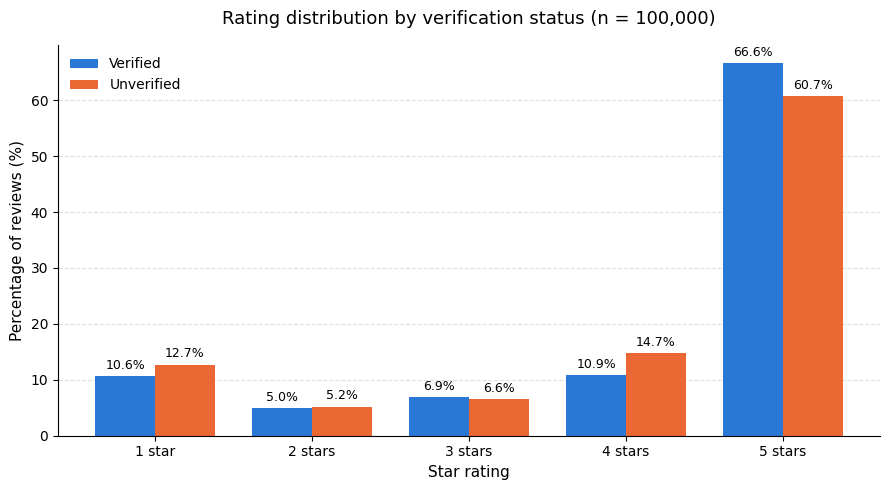

Figure saved to: /content/drive/MyDrive/MSc-Project/outputs/rating_distribution.png


In [16]:
# Step 11: Visualisation of the rating distribution
# The rating distribution is plotted as a grouped bar chart so that the
# proportion of reviews at each star rating can be compared directly
# between the two groups. The figure is saved at 300 dpi to the project
# outputs directory for inclusion in the dissertation.

import matplotlib.pyplot as plt

# The percentage distribution is recalculated for plotting
plot_data = pd.crosstab(
    reviews_df["rating"],
    reviews_df["verified_purchase"],
    normalize="columns"
) * 100

ratings = plot_data.index.astype(int)
unverified_pct = plot_data[False].values
verified_pct = plot_data[True].values

# Bar positions are offset so that the two groups appear side by side
x = np.arange(len(ratings))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, verified_pct, width,
               label="Verified", color="#2a78d6")
bars2 = ax.bar(x + width/2, unverified_pct, width,
               label="Unverified", color="#eb6834")

# Each bar is labelled with its percentage value
for bars in (bars1, bars2):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.1f}%",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Star rating", fontsize=11)
ax.set_ylabel("Percentage of reviews (%)", fontsize=11)
ax.set_title("Rating distribution by verification status (n = 100,000)",
             fontsize=13, pad=15)
ax.set_xticks(x)
ax.set_xticklabels([f"{r} star" if r == 1 else f"{r} stars" for r in ratings])
ax.legend(frameon=False)

# Gridlines are added on the y-axis only to aid readability
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

# The figure is saved at 300 dpi for use in the dissertation
figure_path = "/content/drive/MyDrive/MSc-Project/outputs/rating_distribution.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()
print("Figure saved to:", figure_path)

In [17]:
# Step 12: Partitioning decision and data export
# Verified reviews are adopted as the primary corpus for three reasons.
# First, verification confirms that the reviewer purchased the product,
# so the sentiment expressed relates to genuine product experience.
# Second, verified reviews constitute 93.3% of the sample and therefore
# represent the dominant form of feedback on the platform. Third, the
# two groups differ substantially in review length (Cohen's d = 0.84),
# meaning that combining them would introduce systematic variation in
# text characteristics into the natural language processing pipeline.
# Unverified reviews are retained as a comparison set rather than
# discarded, so that the influence of verification status can be
# reported as a finding.

# The dataset is partitioned by verification status
verified_df = reviews_df[reviews_df["verified_purchase"] == True].copy()
unverified_df = reviews_df[reviews_df["verified_purchase"] == False].copy()

# Both partitions are saved to Google Drive for use in later stages
verified_df.to_csv("/content/drive/MyDrive/MSc-Project/data/reviews_verified.csv", index=False)
unverified_df.to_csv("/content/drive/MyDrive/MSc-Project/data/reviews_unverified.csv", index=False)

print("Primary corpus (verified):   ", verified_df.shape)
print("Comparison set (unverified): ", unverified_df.shape)
print("\nBoth partitions saved to Google Drive.")

Primary corpus (verified):    (93331, 13)
Comparison set (unverified):  (6669, 13)

Both partitions saved to Google Drive.
